# FIT5149 Assessment 1: Sanctioned Loan Amount Prediction

This notebook starts the assessment from a clean implementation. It establishes the condition of the supplied data, records reproducible evidence for cleaning decisions, constructs lending-related features, and compares three regression model families with the same cross-validation folds.

This is a **model-development notebook**, not yet the final packaged implementation. The Kaggle submission is deliberately postponed until the final model has been selected using internal validation.

## Workflow

1. Load and validate the supplied files.
2. Investigate missing values, sentinel codes, impossible values, redundancy, and the target structure.
3. Define deterministic feature engineering.
4. Compare Ridge, Random Forest, and Histogram Gradient Boosting regression.
5. Diagnose out-of-fold errors and decide the next experiments.

In [1]:
# Import the libraries and set reproducible defaults
from pathlib import Path
import os
import platform
import sys
import time
import warnings

# Limit parallel workers so the notebook remains stable on different machines
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Reuse the same seed and fold count in every experiment
RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

np.random.seed(RANDOM_STATE)

## 1. Load the supplied data

The notebook uses paths relative to its own folder. This avoids machine-specific absolute paths and makes the final implementation easier to reproduce.

In [2]:
# Locate and load the three assignment data files
# Resolve paths relative to the notebook so a teammate can rerun it
DATA_DIR = Path.cwd()
if not (DATA_DIR / "training_set.csv").exists():
    candidate = Path.cwd() / "Assignment" / "A1"
    if (candidate / "training_set.csv").exists():
        DATA_DIR = candidate

# Load labelled training data, unlabelled Kaggle data, and the required template
train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Kaggle test:  {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Submission:   {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")

Training data: 19,322 rows x 29 columns
Kaggle test:  10,000 rows x 28 columns
Submission:   10,000 rows x 2 columns


## 2. File and schema integrity checks

These checks fail early if a supplied file is missing, the row order no longer matches the submission template, or identifiers are duplicated. `application_id` is retained for the final output but excluded from predictors, as required by the data dictionary.

In [3]:
# Validate file shapes, schemas, identifiers, and dates
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

# Fail early if the supplied files or their schemas have changed
assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

# Parse DD/MM/YYYY explicitly to avoid Australian/US date ambiguity
train_dates = pd.to_datetime(train["application_date"], format="%d/%m/%Y", errors="raise")
test_dates = pd.to_datetime(test["application_date"], format="%d/%m/%Y", errors="raise")

# Keep a compact evidence table for the written report
integrity_checks = pd.Series(
    {
        "training_rows": len(train),
        "test_rows": len(test),
        "duplicate_training_rows": int(train.duplicated().sum()),
        "duplicate_test_rows": int(test.duplicated().sum()),
        "duplicate_training_ids": int(train["application_id"].duplicated().sum()),
        "duplicate_test_ids": int(test["application_id"].duplicated().sum()),
        "shared_ids_between_train_and_test": int(
            train["application_id"].isin(test["application_id"]).sum()
        ),
        "training_date_min": train_dates.min().date(),
        "training_date_max": train_dates.max().date(),
        "test_date_min": test_dates.min().date(),
        "test_date_max": test_dates.max().date(),
    }
)

print("All schema and identifier checks passed.")
integrity_checks

All schema and identifier checks passed.


training_rows                             19322
test_rows                                 10000
duplicate_training_rows                       0
duplicate_test_rows                           0
duplicate_training_ids                        0
duplicate_test_ids                            0
shared_ids_between_train_and_test             0
training_date_min                    2023-01-01
training_date_max                    2024-12-30
test_date_min                        2023-01-01
test_date_max                        2024-12-30
dtype: object

## 3. Data quality investigation

The marking guide rewards evidence about the actual dataset rather than a generic checklist. The following audit measures missingness, cardinality, and coded sentinel values for every variable.

In [4]:
# Audit data types, missingness, cardinality, and encoded missing values
quality_audit = pd.DataFrame(
    {
        "dtype": train.dtypes.astype(str),
        "missing_n": train.isna().sum(),
        "missing_pct": 100 * train.isna().mean(),
        "unique_including_missing": train.nunique(dropna=False),
    }
)

# Count -999 separately because pandas does not recognise it as NaN
numeric_columns_raw = train.select_dtypes(include="number").columns
quality_audit["sentinel_minus_999_n"] = [
    int((train[column] == -999).sum()) if column in numeric_columns_raw else 0
    for column in quality_audit.index
]

quality_audit.sort_values(
    ["missing_pct", "sentinel_minus_999_n"], ascending=False
).style.format({"missing_pct": "{:.2f}%"})

,dtype,missing_n,missing_pct,unique_including_missing,sentinel_minus_999_n
property_age_years,float64,6260,32.40%,12773,0
monthly_income_aud,float64,4963,25.69%,12331,0
annual_income_aud,float64,4848,25.09%,14151,0
employment_sector,str,4706,24.36%,19,0
credit_rating,float64,3953,20.46%,11646,0
existing_repayments_aud,float64,2294,11.87%,14910,100
dependants_count,float64,1576,8.16%,10,0
property_value_aud,float64,1178,6.10%,17943,199
income_consistency,str,1077,5.57%,3,0
property_area,str,219,1.13%,4,0


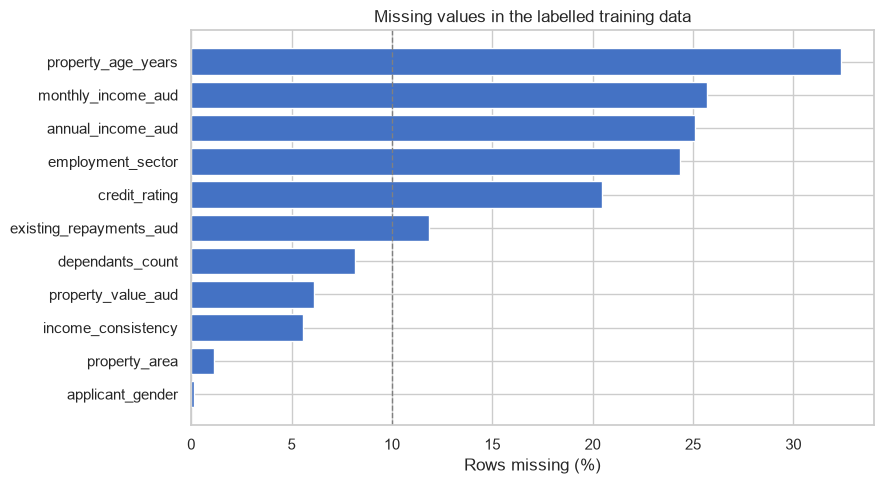

In [5]:
# Visualise only variables containing true NaN values
missing_plot = quality_audit.query("missing_n > 0").sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(missing_plot.index, missing_plot["missing_pct"], color="#4472C4")
ax.set(title="Missing values in the labelled training data", xlabel="Rows missing (%)", ylabel="")
ax.axvline(10, color="grey", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

### 3.1 Missingness differs by variable and may carry signal

Missingness is compared between training and test before any imputation. The target comparison below is descriptive rather than causal: a large difference shows that the absence of a field may be predictive and should not automatically be erased by simple imputation. Specific missingness indicators and an aggregate missing-value count are therefore evaluated in the feature-engineering ablation.

In [6]:
# Compare train and Kaggle-test missingness before imputation
train_missing_pct = 100 * train.isna().mean()
test_missing_pct = 100 * test.isna().mean().reindex(train.columns).fillna(0)

# A positive difference means missingness is higher in the Kaggle test set
missingness_comparison = pd.DataFrame(
    {
        "train_missing_n": train.isna().sum(),
        "train_missing_pct": train_missing_pct,
        "test_missing_n": test.isna().sum().reindex(train.columns).fillna(0).astype(int),
        "test_missing_pct": test_missing_pct,
        "test_minus_train_pct_points": test_missing_pct - train_missing_pct,
    }
).query("train_missing_n > 0 or test_missing_n > 0")

missingness_comparison.sort_values("train_missing_pct", ascending=False).style.format(
    {
        "train_missing_pct": "{:.2f}%",
        "test_missing_pct": "{:.2f}%",
        "test_minus_train_pct_points": "{:+.2f}",
    }
)

,train_missing_n,train_missing_pct,test_missing_n,test_missing_pct,test_minus_train_pct_points
property_age_years,6260,32.40%,3262,32.62%,+0.22
monthly_income_aud,4963,25.69%,2484,24.84%,-0.85
annual_income_aud,4848,25.09%,2485,24.85%,-0.24
employment_sector,4706,24.36%,2419,24.19%,-0.17
credit_rating,3953,20.46%,2133,21.33%,+0.87
existing_repayments_aud,2294,11.87%,1186,11.86%,-0.01
dependants_count,1576,8.16%,826,8.26%,+0.10
property_value_aud,1178,6.10%,581,5.81%,-0.29
income_consistency,1077,5.57%,551,5.51%,-0.06
property_area,219,1.13%,122,1.22%,+0.09


In [7]:
# Check whether missingness is associated with the target
# Convert only confirmed -999 sentinel fields for this diagnostic
train_missing_work = train.copy()
for column in ["existing_repayments_aud", "has_co_applicant", "property_value_aud"]:
    train_missing_work[column] = train_missing_work[column].replace(-999, np.nan)

# Include true NaN fields here. Sentinel fields are added after their definition below.
# Compare target behaviour when each feature is missing versus present
missing_target_rows = []
for column in train.columns.drop(TARGET):
    missing_mask = train_missing_work[column].isna()
    if missing_mask.any() and (~missing_mask).any():
        missing_target_rows.append(
            {
                "feature": column,
                "missing_n": int(missing_mask.sum()),
                "missing_pct": 100 * missing_mask.mean(),
                "mean_target_when_missing": train.loc[missing_mask, TARGET].mean(),
                "mean_target_when_present": train.loc[~missing_mask, TARGET].mean(),
                "target_mean_difference": (
                    train.loc[missing_mask, TARGET].mean()
                    - train.loc[~missing_mask, TARGET].mean()
                ),
                "zero_sanction_when_missing_pct": 100 * (train.loc[missing_mask, TARGET] == 0).mean(),
                "zero_sanction_when_present_pct": 100 * (train.loc[~missing_mask, TARGET] == 0).mean(),
            }
        )

missing_target_evidence = (
    pd.DataFrame(missing_target_rows)
    .assign(abs_target_difference=lambda frame: frame["target_mean_difference"].abs())
    .sort_values("abs_target_difference", ascending=False)
    .drop(columns="abs_target_difference")
)

missing_target_evidence.style.format(
    {
        "missing_pct": "{:.2f}%",
        "mean_target_when_missing": "${:,.0f}",
        "mean_target_when_present": "${:,.0f}",
        "target_mean_difference": "${:+,.0f}",
        "zero_sanction_when_missing_pct": "{:.1f}%",
        "zero_sanction_when_present_pct": "{:.1f}%",
    }
)

,feature,missing_n,missing_pct,mean_target_when_missing,mean_target_when_present,target_mean_difference,zero_sanction_when_missing_pct,zero_sanction_when_present_pct
2,income_consistency,1077,5.57%,"$91,495","$73,868","$+17,627",10.7%,27.7%
4,existing_repayments_aud,2394,12.39%,"$90,259","$72,671","$+17,588",24.9%,27.1%
5,dependants_count,1576,8.16%,"$90,761","$73,437","$+17,323",12.8%,28.0%
8,property_area,219,1.13%,"$90,905","$74,666","$+16,238",9.1%,27.0%
11,monthly_income_aud,4963,25.69%,"$83,407","$71,893","$+11,515",19.4%,29.4%
9,has_co_applicant,107,0.55%,"$84,233","$74,798","$+9,435",21.5%,26.8%
1,annual_income_aud,4848,25.09%,"$81,747","$72,540","$+9,207",20.2%,29.0%
7,property_age_years,6260,32.40%,"$81,003","$71,902","$+9,101",21.0%,29.6%
3,employment_sector,4706,24.36%,"$79,716","$73,284","$+6,432",21.7%,28.4%
6,credit_rating,3953,20.46%,"$77,948","$74,054","$+3,894",22.5%,27.9%


#### Missingness patterns across observable groups

To investigate whether missingness is completely random, the largest within-group difference is calculated for several observable contexts. Large percentage-point spreads indicate that a single global imputation value is unlikely to capture the full pattern. These comparisons remain descriptive and do not prove a missing-data mechanism.

In [8]:
# Identify contexts where missingness is concentrated
missing_context_work = train_missing_work.copy()
# Add calendar year for the audit without modifying the raw training frame
missing_context_work["application_year"] = train_dates.dt.year

missingness_features = [
    "property_age_years",
    "monthly_income_aud",
    "annual_income_aud",
    "employment_sector",
    "credit_rating",
    "existing_repayments_aud",
    "dependants_count",
    "property_value_aud",
]
context_features = [
    "marketing_channel",
    "occupation_class",
    "residence_area",
    "application_year",
]

# Require at least 30 rows per group to avoid unstable percentages
missing_context_rows = []
for missing_feature in missingness_features:
    for context_feature in context_features:
        grouped_missingness = (
            missing_context_work.groupby(context_feature, dropna=False)[missing_feature]
            .agg(group_n="size", missing_rate=lambda values: values.isna().mean())
            .query("group_n >= 30")
        )
        rates = grouped_missingness["missing_rate"].sort_values()
        missing_context_rows.append(
            {
                "missing_feature": missing_feature,
                "grouped_by": context_feature,
                "lowest_missing_group": str(rates.index[0]),
                "lowest_missing_pct": 100 * rates.iloc[0],
                "highest_missing_group": str(rates.index[-1]),
                "highest_missing_pct": 100 * rates.iloc[-1],
                "spread_percentage_points": 100 * (rates.iloc[-1] - rates.iloc[0]),
            }
        )

missingness_by_context = (
    pd.DataFrame(missing_context_rows)
    .sort_values("spread_percentage_points", ascending=False)
    .reset_index(drop=True)
)

missingness_by_context.head(15).style.format(
    {
        "lowest_missing_pct": "{:.1f}%",
        "highest_missing_pct": "{:.1f}%",
        "spread_percentage_points": "{:.1f}",
    }
)

,missing_feature,grouped_by,lowest_missing_group,lowest_missing_pct,highest_missing_group,highest_missing_pct,spread_percentage_points
0,employment_sector,occupation_class,salaried,15.8%,retiree,100.0%,84.2
1,credit_rating,occupation_class,public_sector,11.1%,retiree,46.5%,35.4
2,credit_rating,residence_area,inner_metro,18.7%,regional,25.2%,6.5
3,property_age_years,occupation_class,public_sector,30.7%,retiree,35.5%,4.8
4,monthly_income_aud,occupation_class,public_sector,22.0%,retiree,26.6%,4.6
5,annual_income_aud,occupation_class,public_sector,21.2%,salaried,25.5%,4.3
6,monthly_income_aud,marketing_channel,referral,23.5%,branch_walkin,26.8%,3.3
7,employment_sector,residence_area,outer_metro,24.1%,inner_metro,26.5%,2.5
8,monthly_income_aud,residence_area,outer_metro,25.3%,inner_metro,27.4%,2.2
9,annual_income_aud,residence_area,regional,24.8%,inner_metro,26.9%,2.1


#### Interpretation of missingness

The percentage of missing values is quite similar in the training and test datasets. The largest difference is found in `credit_rating`, which is missing in 20.46% of the training data and 21.33% of the test data. This is a difference of only 0.87 percentage points, so there does not appear to be a major change in missingness between the two datasets.

However, missing values may still contain useful information. For example, the average sanctioned amount is AUD 17,627 higher when `income_consistency` is missing. It is also AUD 17,588 higher when `existing_repayments_aud` is missing. This does not mean that missing values directly cause higher sanctioned amounts, since these applications may also be different in terms of requested amount or other characteristics.

Some missingness patterns are connected to the applicant's situation. `employment_sector` is missing for all retired applicants, compared with only 15.8% of salaried applicants. `credit_rating` is also missing for 46.5% of retired applicants, but only 11.1% of public sector applicants. This suggests that some missing values are related to how the application was recorded and are not completely random.

For this reason, we keep missingness indicators and a total missing-value count as possible predictors. The remaining missing values are imputed inside each cross-validation fold to avoid using information from the validation data during preprocessing.


In [9]:
# Check categorical levels for rarity and train/test mismatch
# Select the categorical variables used in the EDA
categorical_columns_raw = [
    column
    for column in train.select_dtypes(
        include=["object", "string", "category"]
    ).columns
    if column not in ["application_id", "application_date"]
]

# Unseen test levels require an encoder that can handle unknown categories
category_summary = []
for column in categorical_columns_raw:
    train_levels = set(train[column].dropna().unique())
    test_levels = set(test[column].dropna().unique())
    category_summary.append(
        {
            "feature": column,
            "train_levels": len(train_levels),
            "test_levels": len(test_levels),
            "train_only_levels": sorted(train_levels - test_levels),
            "test_only_levels": sorted(test_levels - train_levels),
            "rarest_train_level_n": int(train[column].value_counts().min()),
        }
    )

pd.DataFrame(category_summary)

,feature,train_levels,test_levels,train_only_levels,test_only_levels,rarest_train_level_n
0,applicant_gender,2,2,[],[],9608
1,income_consistency,2,2,[],[],1674
2,occupation_class,8,4,"[no_employment, parental_leave, proprietor, st...",[],1
3,employment_sector,18,18,[],[],47
4,residence_area,3,3,[],[],1994
5,expense_flag_a,2,2,[],[],6935
6,expense_flag_b,2,2,[],[],6370
7,card_status,4,4,[],[],980
8,property_category,4,4,[],[],4630
9,property_area,3,3,[],[],5996


### 3.2 Sentinel codes are missing values, not measurements

The value `-999` appears in variables that cannot meaningfully be negative. It is converted to missing before modelling. Imputation remains inside each model pipeline so that validation folds cannot influence their training folds.

In [10]:
# Quantify the confirmed -999 missing-value codes
# Restrict replacement to fields where negative values are impossible
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

sentinel_counts = pd.DataFrame(
    {
        "training_minus_999": [(train[column] == -999).sum() for column in SENTINEL_COLUMNS],
        "training_pct": [100 * (train[column] == -999).mean() for column in SENTINEL_COLUMNS],
        "test_minus_999": [(test[column] == -999).sum() for column in SENTINEL_COLUMNS],
        "test_pct": [100 * (test[column] == -999).mean() for column in SENTINEL_COLUMNS],
    },
    index=SENTINEL_COLUMNS,
)
sentinel_counts.style.format({"training_pct": "{:.2f}%", "test_pct": "{:.2f}%"})

,training_minus_999,training_pct,test_minus_999,test_pct
existing_repayments_aud,100,0.52%,50,0.50%
has_co_applicant,107,0.55%,53,0.53%
property_value_aud,199,1.03%,110,1.10%


### 3.3 `property_age_years` is not a plausible property age

The values in `property_age_years` do not look like realistic property ages. There are 11,524 rows where both `property_age_years` and `annual_income_aud` are available, and the values are exactly the same in every one of these rows. There are also no property-age values between 0 and 200 years. This strongly suggests that the column contains a copy of annual income instead of the actual age of the property.

Because of this problem, the numeric values from `property_age_years` are not used by the model. We still keep `property_age_years_is_missing` because the presence or absence of this information may be related to how an application was processed. It is also included when calculating the total number of missing values in each application.

We also tested whether this column could be used as a backup when annual income was missing. The Histogram Gradient Boosting model had an RMSE of AUD 36,074 with the backup and AUD 36,065 without it. The difference is only AUD 9 and does not show an improvement, so we decided not to use the corrupted values as an income backup.


In [11]:
# Investigate the suspected property-age corruption
income_property_overlap = train[["annual_income_aud", "property_age_years"]].dropna()
# Test row-level equality rather than relying only on correlation
exact_matches = np.isclose(
    income_property_overlap["annual_income_aud"],
    income_property_overlap["property_age_years"],
    rtol=0,
    atol=0.001,
)

# Cross-check whether annual and monthly income remain internally consistent
income_month_overlap = train[["annual_income_aud", "monthly_income_aud"]].dropna()
annual_to_monthly_ratio = (
    income_month_overlap["annual_income_aud"]
    / income_month_overlap["monthly_income_aud"]
)

data_quality_evidence = pd.Series(
    {
        "rows where annual income and property age both exist": len(income_property_overlap),
        "exact matches between those two fields": int(exact_matches.sum()),
        "plausible property ages between 0 and 200": int(train["property_age_years"].between(0, 200).sum()),
        "correlation of annual and monthly income": income_month_overlap.corr().iloc[0, 1],
        "median annual/monthly income ratio": annual_to_monthly_ratio.median(),
    }
)
data_quality_evidence

rows where annual income and property age both exist   11,524.000
exact matches between those two fields                 11,524.000
plausible property ages between 0 and 200                   0.000
correlation of annual and monthly income                    1.000
median annual/monthly income ratio                         11.999
dtype: float64

#### Annual and monthly income consistency

Annual and monthly income appear to describe the same information at different time scales. The following analysis checks how closely they agree and whether having two fields helps when one of them is missing.

In [12]:
# Compare the availability of annual and monthly income
income_work = train[
    ["annual_income_aud", "monthly_income_aud"]
].copy()

annual_available = income_work["annual_income_aud"].notna()
monthly_available = income_work["monthly_income_aud"].notna()

both_income_available = annual_available & monthly_available
annual_only_available = annual_available & ~monthly_available
monthly_only_available = ~annual_available & monthly_available
neither_income_available = ~annual_available & ~monthly_available

income_availability = pd.Series(
    {
        "both_income_fields_available": int(
            both_income_available.sum()
        ),
        "annual_income_only": int(
            annual_only_available.sum()
        ),
        "monthly_income_only": int(
            monthly_only_available.sum()
        ),
        "neither_income_field_available": int(
            neither_income_available.sum()
        ),
        "both_income_fields_available_pct": (
            100 * both_income_available.mean()
        ),
    }
)

# Annualise monthly income so both fields use the same time scale
income_work["annualised_monthly_income_aud"] = (
    12 * income_work["monthly_income_aud"]
)

income_overlap = income_work.loc[
    both_income_available
].copy()

income_overlap["annual_to_monthly_ratio"] = (
    income_overlap["annual_income_aud"]
    / income_overlap["monthly_income_aud"]
)

income_overlap["relative_income_gap"] = (
    (
        income_overlap["annual_income_aud"]
        - income_overlap["annualised_monthly_income_aud"]
    ).abs()
    / income_overlap["annual_income_aud"].replace(0, np.nan)
)

income_consistency_evidence = pd.Series(
    {
        "pearson_correlation": (
            income_overlap[
                ["annual_income_aud", "monthly_income_aud"]
            ]
            .corr()
            .iloc[0, 1]
        ),
        "median_annual_to_monthly_ratio": (
            income_overlap["annual_to_monthly_ratio"].median()
        ),
        "median_relative_gap_pct": (
            100
            * income_overlap["relative_income_gap"].median()
        ),
        "p95_relative_gap_pct": (
            100
            * income_overlap[
                "relative_income_gap"
            ].quantile(0.95)
        ),
        "rows_within_5_pct": int(
            (
                income_overlap["relative_income_gap"] <= 0.05
            ).sum()
        ),
        "rows_within_5_pct_pct": (
            100
            * (
                income_overlap["relative_income_gap"] <= 0.05
            ).mean()
        ),
    }
)

display(income_availability)
display(income_consistency_evidence)

both_income_fields_available       13,712.000
annual_income_only                    762.000
monthly_income_only                   647.000
neither_income_field_available      4,201.000
both_income_fields_available_pct       70.966
dtype: float64

pearson_correlation                   1.000
median_annual_to_monthly_ratio       11.999
median_relative_gap_pct               2.402
p95_relative_gap_pct                  6.835
rows_within_5_pct                11,590.000
rows_within_5_pct_pct                84.525
dtype: float64

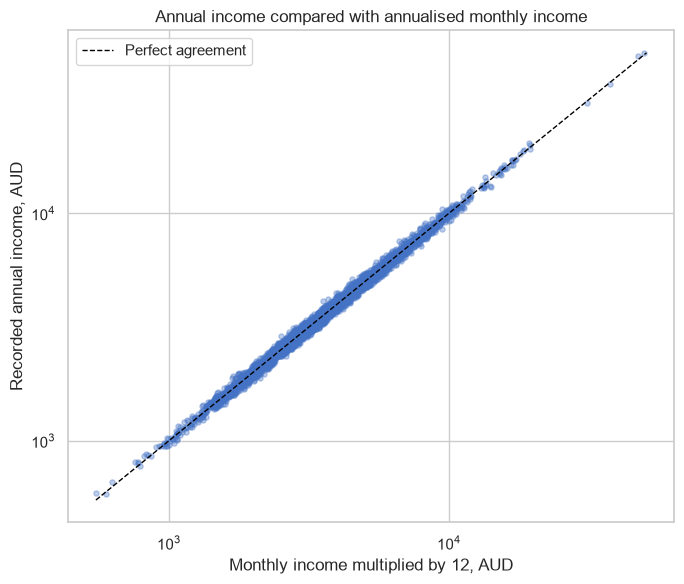

In [13]:
# Plot both income fields on the same annual scale
income_plot = income_overlap.sample(
    n=min(5_000, len(income_overlap)),
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    income_plot["annualised_monthly_income_aud"],
    income_plot["annual_income_aud"],
    alpha=0.35,
    s=14,
    color="#4472C4",
)

plot_min = min(
    income_plot["annualised_monthly_income_aud"].min(),
    income_plot["annual_income_aud"].min(),
)

plot_max = max(
    income_plot["annualised_monthly_income_aud"].max(),
    income_plot["annual_income_aud"].max(),
)

ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color="black",
    linestyle="--",
    linewidth=1,
    label="Perfect agreement",
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set(
    title="Annual income compared with annualised monthly income",
    xlabel="Monthly income multiplied by 12, AUD",
    ylabel="Recorded annual income, AUD",
)

ax.legend()
plt.tight_layout()
plt.show()

#### Interpretation of income consistency

Annual and monthly income contain almost the same information when both values are available. Their Pearson correlation is approximately 0.99996, and the median annual-to-monthly ratio is 11.999, which is very close to the expected ratio of 12.

The median difference between recorded annual income and annualised monthly income is 2.4%. Around 84.5% of the overlapping rows have a difference of no more than 5%. This suggests that the two fields are highly consistent but not always exactly equal.

Both income values are available for 13,712 applications, representing 70.97% of the training data. However, 762 applications contain only annual income and 647 contain only monthly income. A further 4,201 applications have neither value available.

Although the two fields are highly redundant when both are present, they can support each other when one value is missing. For this reason, we create a reconciled annual-income feature using the available income sources. The original income fields are kept during the initial modelling stage, but we will later compare this approach with using only the reconciled feature through cross-validation.

### 3.4 Business-rule checks, extreme values, and dataset shift

The following checks distinguish demonstrably invalid observations from merely extreme observations. Extreme but possible values are retained for modelling; hard corrections are limited to the documented `-999` sentinels and the corrupted property-age field.

Train/test shift is summarised using standardised mean differences for numeric fields and total-variation distance for categorical fields. These measures are descriptive screening tools, not hypothesis tests.

In [14]:
# Run business-rule checks and inspect robust numeric ranges
train_clean_for_audit = train.copy()
test_clean_for_audit = test.copy()
# Clean confirmed sentinels for auditing; do not alter the source frames
for column in SENTINEL_COLUMNS:
    train_clean_for_audit[column] = train_clean_for_audit[column].replace(-999, np.nan)
    test_clean_for_audit[column] = test_clean_for_audit[column].replace(-999, np.nan)

# Count hard rule violations instead of deleting extreme rows automatically
business_rule_checks = pd.Series(
    {
        "requested_amount_nonpositive": int((train["requested_amount_aud"] <= 0).sum()),
        "sanctioned_amount_negative": int((train[TARGET] < 0).sum()),
        "sanctioned_above_requested": int((train[TARGET] > train["requested_amount_aud"]).sum()),
        "applicant_age_below_18": int((train["applicant_age"] < 18).sum()),
        "applicant_age_above_100": int((train["applicant_age"] > 100).sum()),
        "annual_income_nonpositive": int((train["annual_income_aud"] <= 0).sum()),
        "monthly_income_nonpositive": int((train["monthly_income_aud"] <= 0).sum()),
        "property_value_nonpositive_after_sentinel_cleaning": int(
            (train_clean_for_audit["property_value_aud"] <= 0).sum()
        ),
        "repayments_negative_after_sentinel_cleaning": int(
            (train_clean_for_audit["existing_repayments_aud"] < 0).sum()
        ),
    }
)

# Use the 1st and 99th percentiles to reveal skew without hiding extremes
numeric_summary = (
    train_clean_for_audit.select_dtypes(include="number")
    .drop(columns=TARGET)
    .quantile([0, 0.01, 0.5, 0.99, 1])
    .T
    .rename(columns={0.0: "min", 0.01: "p01", 0.5: "median", 0.99: "p99", 1.0: "max"})
)

display(business_rule_checks)
display(numeric_summary.style.format("{:,.2f}"))

requested_amount_nonpositive                          0
sanctioned_amount_negative                            0
sanctioned_above_requested                            0
applicant_age_below_18                                0
applicant_age_above_100                               0
annual_income_nonpositive                             0
monthly_income_nonpositive                            0
property_value_nonpositive_after_sentinel_cleaning    0
repayments_negative_after_sentinel_cleaning           0
dtype: int64

,min,p01,median,p99,max
applicant_age,18.00,18.00,40.00,65.00,65.00
annual_income_aud,585.43,"1,165.84","3,411.84","11,810.78","2,755,063.33"
requested_amount_aud,"9,467.48","18,167.70","116,439.51","429,442.27","933,695.43"
existing_repayments_aud,52.76,140.44,566.30,"1,617.95","5,953.36"
dependants_count,1.00,1.00,2.00,5.00,10.00
credit_rating,580.85,600.55,737.23,872.77,891.95
prior_default_count,0.00,0.00,0.00,1.00,1.00
property_ref,1.00,11.00,502.00,989.79,999.00
property_age_years,585.43,"1,156.66","3,401.61","11,815.13","2,755,063.33"
has_co_applicant,0.00,0.00,1.00,1.00,1.00


In [15]:
# Screen for marginal distribution shift between train and test
common_numeric = [
    column
    for column in train_clean_for_audit.select_dtypes(include="number").columns
    if column in test_clean_for_audit.columns and column not in ["property_age_years", "property_ref"]
]

# Standardised mean difference makes numeric features comparable across scales
numeric_shift_rows = []
for column in common_numeric:
    train_values = train_clean_for_audit[column].dropna()
    test_values = test_clean_for_audit[column].dropna()
    pooled_sd = np.sqrt((train_values.var() + test_values.var()) / 2)
    smd = (test_values.mean() - train_values.mean()) / pooled_sd if pooled_sd > 0 else 0
    numeric_shift_rows.append(
        {
            "feature": column,
            "train_mean": train_values.mean(),
            "test_mean": test_values.mean(),
            "standardised_mean_difference": smd,
        }
    )

# Total variation distance compares complete categorical distributions
categorical_shift_rows = []
for column in categorical_columns_raw:
    train_share = train[column].fillna("Missing").value_counts(normalize=True)
    test_share = test[column].fillna("Missing").value_counts(normalize=True)
    all_levels = train_share.index.union(test_share.index)
    total_variation = 0.5 * (
        train_share.reindex(all_levels, fill_value=0)
        - test_share.reindex(all_levels, fill_value=0)
    ).abs().sum()
    categorical_shift_rows.append(
        {"feature": column, "total_variation_distance": total_variation}
    )

numeric_shift = pd.DataFrame(numeric_shift_rows).sort_values(
    "standardised_mean_difference", key=lambda values: values.abs(), ascending=False
)
categorical_shift = pd.DataFrame(categorical_shift_rows).sort_values(
    "total_variation_distance", ascending=False
)

display(numeric_shift.style.format({
    "train_mean": "{:,.2f}",
    "test_mean": "{:,.2f}",
    "standardised_mean_difference": "{:+.3f}",
}))
display(categorical_shift.style.format({"total_variation_distance": "{:.3f}"}))

,feature,train_mean,test_mean,standardised_mean_difference
0,applicant_age,40.24,39.89,-0.022
4,dependants_count,2.25,2.26,+0.013
3,existing_repayments_aud,616.61,620.41,+0.011
5,credit_rating,737.79,736.97,-0.011
11,enquiry_count_12m,3.73,3.70,-0.011
1,annual_income_aud,"4,165.23","3,994.20",-0.010
9,monthly_income_aud,346.76,332.00,-0.010
8,property_value_aud,"205,915.64","207,315.24",+0.010
2,requested_amount_aud,"137,378.44","138,053.65",+0.007
7,has_co_applicant,0.85,0.85,-0.006


,feature,total_variation_distance
11,branch_id,0.061
3,employment_sector,0.015
8,property_category,0.012
7,card_status,0.011
9,property_area,0.009
4,residence_area,0.008
10,marketing_channel,0.006
6,expense_flag_b,0.006
2,occupation_class,0.005
0,applicant_gender,0.003


### 3.5 Univariate relationships with the target

Pearson correlation measures linear association, while Spearman correlation also captures monotonic nonlinear relationships. The categorical summary reports the spread in mean sanctioned amount across adequately represented levels. These are screening statistics only: they do not control for requested loan size or establish causal influence.

In [16]:
# Rank numeric and categorical relationships with the target
numeric_for_relationships = train_clean_for_audit.select_dtypes(include="number").drop(
    columns=["property_age_years", "property_ref"]
)

# Pearson measures linear association; Spearman captures monotonic association
numeric_target_relationships = pd.DataFrame(
    {
        "pearson_with_target": numeric_for_relationships.corr(method="pearson")[TARGET],
        "spearman_with_target": numeric_for_relationships.corr(method="spearman")[TARGET],
    }
).drop(index=TARGET)
numeric_target_relationships["max_absolute_relationship"] = numeric_target_relationships.abs().max(axis=1)
numeric_target_relationships = numeric_target_relationships.sort_values(
    "max_absolute_relationship", ascending=False
)

# Ignore category levels with fewer than 30 rows when comparing target means
categorical_target_rows = []
for column in categorical_columns_raw:
    grouped = (
        train.assign(_category=train[column].fillna("Missing"))
        .groupby("_category", dropna=False)[TARGET]
        .agg(["size", "mean"])
        .query("size >= 30")
    )
    categorical_target_rows.append(
        {
            "feature": column,
            "eligible_levels": len(grouped),
            "minimum_level_mean_target": grouped["mean"].min(),
            "maximum_level_mean_target": grouped["mean"].max(),
            "mean_target_spread": grouped["mean"].max() - grouped["mean"].min(),
        }
    )

categorical_target_relationships = pd.DataFrame(categorical_target_rows).sort_values(
    "mean_target_spread", ascending=False
)

display(numeric_target_relationships.style.format("{:+.3f}"))
display(categorical_target_relationships.style.format({
    "minimum_level_mean_target": "${:,.0f}",
    "maximum_level_mean_target": "${:,.0f}",
    "mean_target_spread": "${:,.0f}",
}))

,pearson_with_target,spearman_with_target,max_absolute_relationship
requested_amount_aud,+0.740,+0.601,+0.740
property_value_aud,+0.712,+0.582,+0.712
existing_repayments_aud,+0.563,+0.481,+0.563
credit_rating,+0.375,+0.404,+0.404
has_co_applicant,+0.269,+0.350,+0.350
annual_income_aud,+0.030,+0.225,+0.225
monthly_income_aud,+0.029,+0.220,+0.220
risk_review_flag,-0.114,-0.127,+0.127
applicant_age,+0.006,+0.016,+0.016
dependants_count,+0.008,+0.016,+0.016


,feature,eligible_levels,minimum_level_mean_target,maximum_level_mean_target,mean_target_spread
11,branch_id,200,"$50,044","$128,894","$78,850"
3,employment_sector,19,"$43,807","$105,106","$61,298"
4,residence_area,3,"$68,024","$102,847","$34,823"
7,card_status,4,"$73,494","$92,705","$19,211"
1,income_consistency,3,"$72,910","$91,495","$18,585"
2,occupation_class,4,"$68,254","$85,434","$17,180"
9,property_area,4,"$74,217","$90,905","$16,687"
5,expense_flag_a,2,"$71,154","$81,453","$10,299"
10,marketing_channel,5,"$71,959","$76,820","$4,861"
0,applicant_gender,2,"$74,207","$75,496","$1,288"


In [17]:
# Audit property_ref as an identifier rather than a numeric measurement
train_property_refs = set(train["property_ref"].dropna().unique())
test_property_refs = set(test["property_ref"].dropna().unique())

property_ref_counts = train["property_ref"].value_counts()

property_ref_audit = pd.Series(
    {
        "unique_references_in_train": len(train_property_refs),
        "unique_references_in_test": len(test_property_refs),
        "test_references_seen_in_train_pct": (
            100
            * len(test_property_refs.intersection(train_property_refs))
            / len(test_property_refs)
        ),
        "median_train_applications_per_reference": property_ref_counts.median(),
        "maximum_train_applications_per_reference": property_ref_counts.max(),
    }
)

property_ref_audit

unique_references_in_train                 999.000
unique_references_in_test                  999.000
test_references_seen_in_train_pct          100.000
median_train_applications_per_reference     19.000
maximum_train_applications_per_reference    34.000
dtype: float64

#### Treatment of `property_ref`

According to the data dictionary, `property_ref` is an internal reference number and not a continuous numeric measurement. This means that its average value and numeric correlation with the target do not have a useful interpretation. For this reason, it should be assessed separately as an identifier and then represented as a categorical variable for modelling.

There are 999 different property references in both the training and test datasets. All the references found in the test data are also present in the training data. Each reference appears more than once, with a median of 19 applications and a maximum of 34 applications per reference.

Since the references are repeated and all test references are already present in training, the variable may contain useful information about groups of applications. We therefore treat it as a categorical variable for the initial models. However, we still need to compare the model with and without this variable because identifiers with many categories can sometimes lead to overfitting.


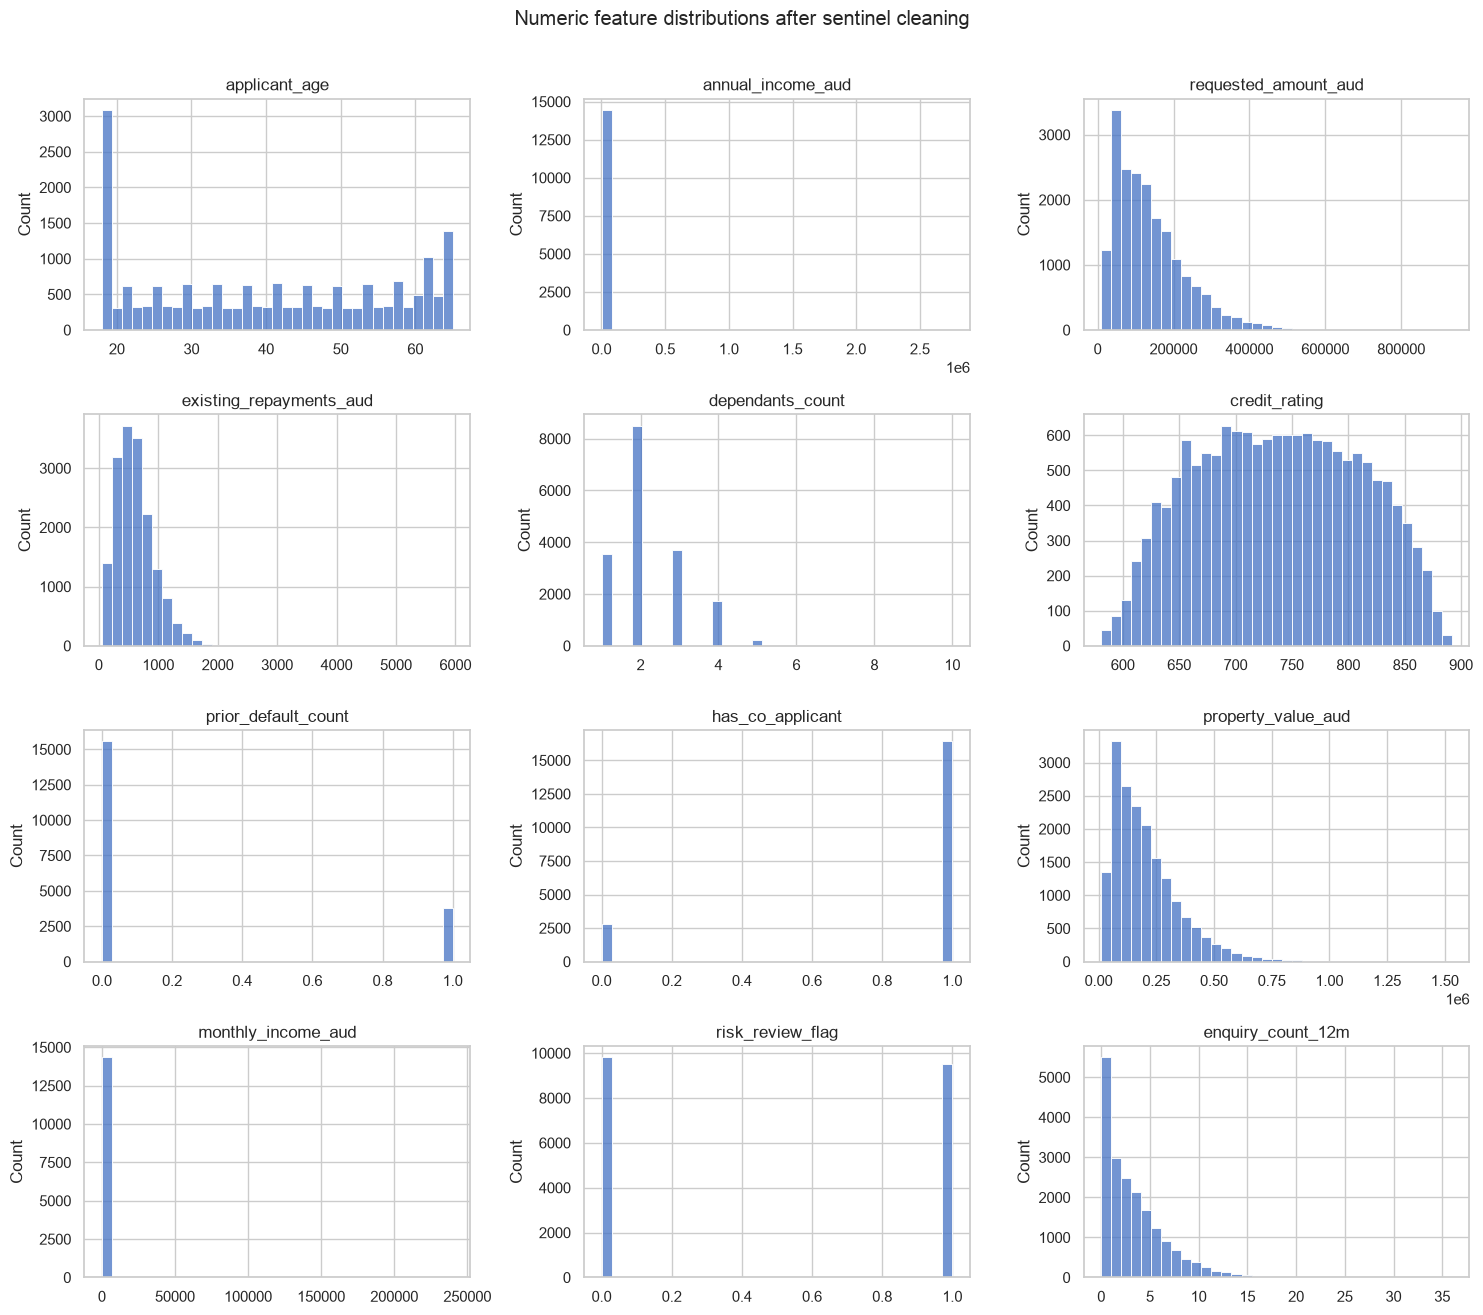

In [18]:
# Plot cleaned numeric distributions to reveal skew and outliers
# Exclude the target and the ID-like property reference from histograms
distribution_columns = [
    column
    for column in numeric_for_relationships.columns
    if column not in [TARGET, "property_ref"]
]

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for column, ax in zip(distribution_columns, axes.flat):
    values = train_clean_for_audit[column].dropna()
    sns.histplot(values, bins=35, ax=ax, color="#4472C4")
    ax.set_title(column)
    ax.set_xlabel("")

for ax in axes.flat[len(distribution_columns):]:
    ax.set_visible(False)

fig.suptitle("Numeric feature distributions after sentinel cleaning", y=1.01)
plt.tight_layout()
plt.show()

## 4. Target investigation

RMSE is sensitive to large errors, so the scale and structure of the target matter. Here, 26.8% of labelled applications have zero sanctioned amount. For every row, the sanctioned amount is no greater than the requested amount.

More unusually, the sanctioned amount is almost exactly a fixed proportion of the requested amount. The observed proportions are 0%, 65%, 70%, 75%, 80%, 85%, 90%, and 100%. This suggests a tiered underwriting decision. It motivates stratifying validation folds by sanction tier and testing a rate-based model later, while the initial comparison below remains a direct regression on AUD.

In [19]:
# Examine the target as both an amount and a share of the request
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
# Rounded ratios reveal the discrete underwriting decision tiers
sanction_rate = (y / requested).round(2)

target_checks = pd.Series(
    {
        "zero_target_n": int((y == 0).sum()),
        "zero_target_pct": 100 * (y == 0).mean(),
        "sanction_above_request_n": int((y > requested).sum()),
        "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
    }
)
target_checks

zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

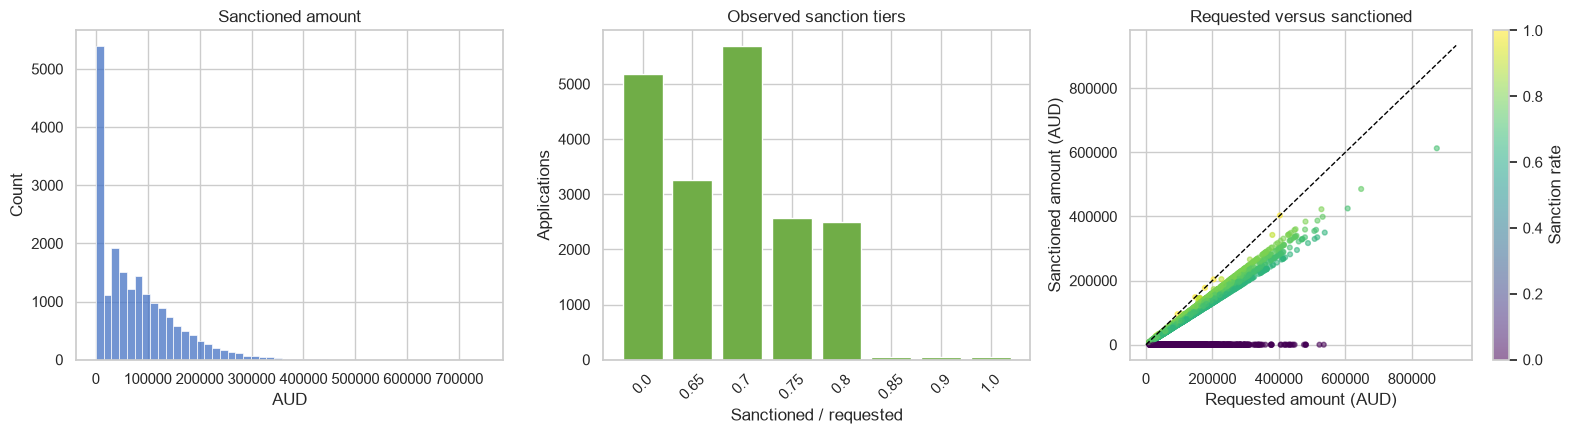

In [20]:
# Visualise target imbalance, decision tiers, and the lending constraint
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(y, bins=50, ax=axes[0], color="#4472C4")
axes[0].set(title="Sanctioned amount", xlabel="AUD")

rate_counts = sanction_rate.value_counts().sort_index()
axes[1].bar(rate_counts.index.astype(str), rate_counts.values, color="#70AD47")
axes[1].set(title="Observed sanction tiers", xlabel="Sanctioned / requested", ylabel="Applications")
axes[1].tick_params(axis="x", rotation=45)

# Sample the scatter plot for readability while keeping the full-data summaries
sample_for_plot = train.sample(n=min(4_000, len(train)), random_state=RANDOM_STATE)
sample_rate = (sample_for_plot[TARGET] / sample_for_plot["requested_amount_aud"]).round(2)
scatter = axes[2].scatter(
    sample_for_plot["requested_amount_aud"],
    sample_for_plot[TARGET],
    c=sample_rate,
    cmap="viridis",
    s=12,
    alpha=0.55,
)
axes[2].plot([0, requested.max()], [0, requested.max()], color="black", linestyle="--", linewidth=1)
axes[2].set(title="Requested versus sanctioned", xlabel="Requested amount (AUD)", ylabel="Sanctioned amount (AUD)")
fig.colorbar(scatter, ax=axes[2], label="Sanction rate")

plt.tight_layout()
plt.show()

### 4.1 Categorical patterns in rejection and sanction rates

The previous analysis compared the average sanctioned amount across categories. However, this amount is affected by how much each group requested. To make the groups more comparable, we also examine the average sanction rate and the percentage of rejected applications.

In [21]:
# Prepare scale-free target measures for categorical comparisons
categorical_eda = train.copy()
categorical_eda["sanction_rate"] = (
    categorical_eda[TARGET]
    / categorical_eda["requested_amount_aud"]
)
categorical_eda["is_rejected"] = (
    categorical_eda[TARGET] == 0
).astype(int)

selected_categorical_features = [
    "occupation_class",
    "employment_sector",
    "residence_area",
    "income_consistency",
]

category_summary_frames = []

for feature in selected_categorical_features:
    grouped_summary = (
        categorical_eda.assign(
            category=categorical_eda[feature].fillna("Missing")
        )
        .groupby("category", dropna=False)
        .agg(
            applications=(TARGET, "size"),
            mean_requested_amount=(
                "requested_amount_aud",
                "mean",
            ),
            mean_sanctioned_amount=(TARGET, "mean"),
            mean_sanction_rate=("sanction_rate", "mean"),
            rejection_rate=("is_rejected", "mean"),
        )
        .query("applications >= 30")
        .reset_index()
    )

    grouped_summary.insert(0, "feature", feature)
    category_summary_frames.append(grouped_summary)

categorical_target_summary = pd.concat(
    category_summary_frames,
    ignore_index=True,
)

categorical_target_summary = categorical_target_summary.sort_values(
    ["feature", "rejection_rate"]
)

categorical_target_summary.style.format(
    {
        "applications": "{:,.0f}",
        "mean_requested_amount": "${:,.0f}",
        "mean_sanctioned_amount": "${:,.0f}",
        "mean_sanction_rate": "{:.1%}",
        "rejection_rate": "{:.1%}",
    }
)

,feature,category,applications,mean_requested_amount,mean_sanctioned_amount,mean_sanction_rate,rejection_rate
14,employment_sector,information_technology,47,"$142,648","$75,473",58.3%,19.1%
17,employment_sector,personal_services,211,"$129,538","$75,866",57.4%,19.4%
8,employment_sector,finance,900,"$158,026","$94,701",58.5%,19.8%
16,employment_sector,management,"1,572","$174,979","$105,106",58.0%,19.8%
11,employment_sector,healthcare,572,"$131,792","$76,402",56.8%,21.0%
7,employment_sector,facilities,231,"$117,176","$70,325",57.1%,21.2%
13,employment_sector,human_resources,47,"$157,169","$96,622",57.7%,21.3%
4,employment_sector,Missing,"4,706","$137,777","$79,716",57.0%,21.7%
18,employment_sector,property_services,60,"$128,860","$73,083",55.3%,21.7%
6,employment_sector,clerical,100,"$134,142","$80,476",56.5%,22.0%


In [22]:
# Divide credit rating into five similarly sized groups
credit_rating_work = categorical_eda.copy()

credit_rating_work["credit_rating_band"] = pd.qcut(
    credit_rating_work["credit_rating"],
    q=5,
    duplicates="drop",
)

credit_rating_work["credit_rating_band"] = (
    credit_rating_work["credit_rating_band"]
    .astype("string")
    .fillna("Missing")
)

credit_rating_summary = (
    credit_rating_work
    .groupby("credit_rating_band", dropna=False)
    .agg(
        applications=(TARGET, "size"),
        mean_credit_rating=("credit_rating", "mean"),
        mean_requested_amount=(
            "requested_amount_aud",
            "mean",
        ),
        mean_sanction_rate=("sanction_rate", "mean"),
        rejection_rate=("is_rejected", "mean"),
    )
    .reset_index()
    .sort_values(
        "mean_credit_rating",
        na_position="last",
    )
)

credit_rating_summary.style.format(
    {
        "applications": "{:,.0f}",
        "mean_credit_rating": "{:,.0f}",
        "mean_requested_amount": "${:,.0f}",
        "mean_sanction_rate": "{:.1%}",
        "rejection_rate": "{:.1%}",
    }
)

,credit_rating_band,applications,mean_credit_rating,mean_requested_amount,mean_sanction_rate,rejection_rate
0,"(580.849, 667.66]","3,075",638,"$112,164",19.6%,70.9%
1,"(667.66, 714.24]","3,075",692,"$126,658",54.8%,18.9%
2,"(714.24, 760.148]","3,071",737,"$139,687",57.2%,17.5%
3,"(760.148, 808.184]","3,074",784,"$149,037",60.1%,19.9%
4,"(808.184, 891.95]","3,074",838,"$160,185",66.4%,12.3%
5,Missing,"3,953",nan,"$136,737",55.9%,22.5%


In [23]:
# Summarise branch differences without displaying all 200 branches
branch_summary = (
    categorical_eda
    .groupby("branch_id")
    .agg(
        applications=(TARGET, "size"),
        mean_requested_amount=(
            "requested_amount_aud",
            "mean",
        ),
        mean_sanction_rate=("sanction_rate", "mean"),
        rejection_rate=("is_rejected", "mean"),
    )
    .query("applications >= 30")
)

lowest_rejection_branches = branch_summary.nsmallest(
    5,
    "rejection_rate",
)

highest_rejection_branches = branch_summary.nlargest(
    5,
    "rejection_rate",
)

branch_extremes = pd.concat(
    [
        lowest_rejection_branches,
        highest_rejection_branches,
    ]
).sort_values("rejection_rate")

branch_extremes.style.format(
    {
        "applications": "{:,.0f}",
        "mean_requested_amount": "${:,.0f}",
        "mean_sanction_rate": "{:.1%}",
        "rejection_rate": "{:.1%}",
    }
)

,applications,mean_requested_amount,mean_sanction_rate,rejection_rate
branch_id,,,,
BR125,45,"$193,523",63.8%,11.1%
BR007,59,"$135,722",61.8%,13.6%
BR181,47,"$169,546",61.0%,14.9%
BR050,60,"$135,760",62.1%,15.0%
BR196,59,"$127,156",59.9%,16.9%
BR197,54,"$125,056",43.8%,37.0%
BR085,65,"$129,279",43.8%,38.5%
BR075,57,"$145,037",43.4%,38.6%
BR191,48,"$152,000",43.9%,39.6%


#### Interpretation of categorical patterns

The categorical comparisons show that differences in sanctioned amounts are not only explained by differences in the amount requested.

`credit_rating` has one of the clearest relationships with the lending decision. The group with the lowest credit ratings has a rejection rate of 70.9% and an average sanction rate of 19.6%. In comparison, the group with the highest credit ratings has a rejection rate of 12.3% and an average sanction rate of 66.4%. This is consistent with higher credit ratings representing lower assessed risk.

There are also noticeable differences between occupation groups. Salaried applicants have a rejection rate of 29.3%, compared with 14.4% for retired applicants. However, employment information is often missing for retired applicants, so occupation and missingness should be considered together.

Residence area also shows a smaller difference. Regional applicants have a rejection rate of 30.4% and an average sanction rate of 49.4%, while applicants from inner metropolitan areas have a rejection rate of 22.0% and an average sanction rate of 56.9%.

Applications with steady income have a rejection rate of 15.4%, compared with 29.0% for applications with variable income. The missing category has an even lower rejection rate of 10.7%, which supports the earlier finding that missingness may contain information.

Rejection rates also vary across branches, from approximately 11.1% to 40.0%. These differences should be interpreted carefully because some branches have relatively few applications and may serve applicants with different characteristics. The results show an association, but they do not prove that the branch itself causes a different lending decision.

## 5. Deterministic cleaning and feature engineering

Only transformations that do not learn from other rows are performed before cross-validation. All learned steps, including imputation, scaling, and category encoding, remain inside the pipelines.

The constructed features reflect lending decisions:

- requested amount relative to property value;
- requested amount relative to reconciled annual income;
- existing repayments relative to reconciled monthly income;
- property value remaining after the requested loan;
- cyclical calendar position and application year;
- specific missingness indicators and an aggregate missing-value count.

The function has explicit switches so that the value of these choices can be measured with the same folds in the ablation study rather than asserted without evidence.

In [24]:
# Apply deterministic feature engineering shared by train and test
MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]


def engineer_features(
    frame,
    *,
    use_income_backup=False,
    add_business_features=True,
    add_missing_indicators=True,
):
    """Create row-wise features without learning information from other rows."""
    x = frame.copy()

    # Convert encoded missing values before counting or imputing them
    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    # Preserve missingness because the audit showed it may be informative
    x["missing_value_count"] = x.isna().sum(axis=1)
    if add_missing_indicators:
        for column in MISSING_INDICATOR_COLUMNS:
            x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    # Encode the date into trend and cyclical seasonal components
    application_date = pd.to_datetime(
        x.pop("application_date"), format="%d/%m/%Y", errors="raise"
    )
    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(2 * np.pi * application_date.dt.month / 12)
    x["application_month_cos"] = np.cos(2 * np.pi * application_date.dt.month / 12)
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    # Add affordability and security ratios motivated by lending logic
    if add_business_features:
        income_candidates = [x["annual_income_aud"], 12 * x["monthly_income_aud"]]
        # Test the corrupted property-age field only in the explicit ablation
        if use_income_backup:
            income_candidates.append(x["property_age_years"])
        income_candidates = pd.concat(income_candidates, axis=1)

        x["annual_income_reconciled_aud"] = income_candidates.median(axis=1, skipna=True)
        x["income_sources_available"] = income_candidates.notna().sum(axis=1)
        x["income_relative_gap"] = (
            (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
            / x["annual_income_reconciled_aud"].replace(0, np.nan)
        )
        x["requested_to_property_value"] = (
            x["requested_amount_aud"] / x["property_value_aud"].replace(0, np.nan)
        )
        x["requested_to_annual_income"] = (
            x["requested_amount_aud"]
            / x["annual_income_reconciled_aud"].replace(0, np.nan)
        )
        x["repayments_to_monthly_income"] = (
            x["existing_repayments_aud"]
            / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
        )
        x["property_value_minus_requested"] = (
            x["property_value_aud"] - x["requested_amount_aud"]
        )

    # Remove the row identifier and the corrupted property-age field
    x = x.drop(columns=["application_id", "property_age_years"])

    # Treat the repeated internal reference as a category, not a continuous number.
    x["property_ref"] = x["property_ref"].astype("string")
    return x


# Apply exactly the same deterministic transformations to both datasets
X = engineer_features(train.drop(columns=TARGET))
X_kaggle = engineer_features(test)

assert X.columns.tolist() == X_kaggle.columns.tolist()
assert not np.isinf(X.select_dtypes(include="number").to_numpy()).any()

print(f"Model matrix before learned preprocessing: {X.shape}")
print(f"Reconciled income remains missing for {X['annual_income_reconciled_aud'].isna().sum():,} rows")
X.head()

Model matrix before learned preprocessing: (19322, 50)
Reconciled income remains missing for 4,201 rows


,applicant_gender,applicant_age,annual_income_aud,income_consistency,occupation_class,employment_sector,residence_area,requested_amount_aud,existing_repayments_aud,expense_flag_a,expense_flag_b,dependants_count,credit_rating,prior_default_count,card_status,property_ref,property_category,property_area,has_co_applicant,property_value_aud,marketing_channel,branch_id,monthly_income_aud,risk_review_flag,enquiry_count_12m,missing_value_count,applicant_gender_is_missing,annual_income_aud_is_missing,income_consistency_is_missing,employment_sector_is_missing,existing_repayments_aud_is_missing,dependants_count_is_missing,credit_rating_is_missing,property_age_years_is_missing,property_area_is_missing,has_co_applicant_is_missing,property_value_aud_is_missing,monthly_income_aud_is_missing,application_year,application_month_sin,application_month_cos,application_dayofyear_sin,application_dayofyear_cos,annual_income_reconciled_aud,income_sources_available,income_relative_gap,requested_to_property_value,requested_to_annual_income,repayments_to_monthly_income,property_value_minus_requested
0,male,65,"3,572.420",steady,retiree,NaN,outer_metro,"80,823.310",369.810,no,yes,NaN,806.520,1,current,77,cat_c,NaN,1.000,"118,370.540",online,BR111,290.870,1,3,3,0,0,0,1,0,1,0,0,1,0,0,0,2024,-0.500,0.866,-0.497,0.868,"3,531.430",2,0.023,0.683,22.887,1.257,"37,547.230"
1,male,48,NaN,variable,salaried,retail,outer_metro,"41,673.080",188.250,no,no,2.000,613.700,1,current,743,cat_b,regional,0.000,"47,000.080",online,BR110,NaN,0,4,3,0,1,0,0,0,0,0,1,0,0,0,1,2023,-1.000,-0.000,-0.995,-0.102,NaN,0,NaN,0.887,NaN,NaN,"5,327.000"
2,female,18,"3,551.480",variable,salaried,retail,outer_metro,"199,076.750",941.270,no,yes,2.000,780.280,0,current,788,cat_b,outer_metro,1.000,"277,686.300",online,BR164,286.620,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,2024,-1.000,-0.000,-0.958,-0.287,"3,495.460",2,0.032,0.717,56.953,3.231,"78,609.550"
3,male,50,NaN,variable,commercial_partner,retail,inner_metro,"120,176.890",309.710,no,yes,2.000,NaN,0,none_held,709,cat_a,outer_metro,1.000,"203,173.220",online,BR051,NaN,1,3,4,0,1,0,0,0,0,1,1,0,0,0,1,2023,-0.500,-0.866,-0.391,-0.920,NaN,0,NaN,0.591,NaN,NaN,"82,996.330"
4,male,28,NaN,NaN,salaried,NaN,outer_metro,"62,745.530",454.490,no,no,NaN,NaN,0,current,772,cat_d,regional,1.000,"86,636.210",branch_walkin,BR072,NaN,1,2,7,0,1,1,1,0,1,1,1,0,0,0,1,2024,-0.000,1.000,-0.292,0.956,NaN,0,NaN,0.724,NaN,NaN,"23,890.680"


## 6. Validation design

The Kaggle public leaderboard uses only 2,000 rows and must not be used as a validation set. This notebook uses five shuffled folds with a fixed seed. Folds are stratified by the eight observed sanction tiers, which keeps the zero-sanction and rarer high-rate regimes represented in every fold.

The same precomputed folds are used for every model, enabling paired comparisons. Preprocessing is fitted separately inside each training fold, preventing leakage from imputation, scaling, or encoding.

In [25]:
# Create reproducible, target-tier-balanced validation folds
# The tier is used only for splitting and is never provided to the models
strata = sanction_rate.map(lambda value: f"{value:.2f}")
splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
# Materialise folds once so every candidate sees identical validation rows
folds = list(splitter.split(X, strata))

fold_balance = []
for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = strata.iloc[valid_index].value_counts(normalize=True).sort_index()
    fold_balance.append(counts.rename(f"fold_{fold_number}"))

pd.concat(fold_balance, axis=1).T.style.format("{:.2%}")

,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


## 7. Preprocessing pipelines and candidate models

The model families are genuinely different:

1. **Ridge regression** is a regularised linear baseline. Numeric inputs are median-imputed and standardised; categorical inputs are imputed and one-hot encoded.
2. **Random Forest regression** captures interactions and nonlinear thresholds through bagged trees.
3. **Histogram Gradient Boosting regression** builds trees sequentially to correct earlier errors and treats encoded categorical columns as categorical features.

Rare categorical levels are handled explicitly. This matters because four occupation labels appear only one or two times in training and do not appear in the Kaggle test set.

In [26]:
# Build leakage-safe preprocessing and three model families
# Detect feature types after deterministic engineering
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in X.columns if column not in categorical_features]

# Ridge needs scaled numeric values and one-hot encoded categories
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            min_frequency=10,
                            sparse_output=True,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

# Tree models use compact ordinal codes and tolerate nonlinear relationships
ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            max_categories=254,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

categorical_mask_after_ordinal = (
    [False] * len(numeric_features) + [True] * len(categorical_features)
)

# Compare a regularised linear baseline with two nonlinear tree approaches
models = {
    "Ridge": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=2,
                    max_features=0.8,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Histogram Gradient Boosting": Pipeline(
        steps=[
            ("preprocess", ordinal_preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask_after_ordinal,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("Candidate families:", ", ".join(models))

Numeric features: 37
Categorical features: 13
Candidate families: Ridge, Random Forest, Histogram Gradient Boosting


## 8. Five-fold model comparison

For each validation fold, the notebook reports raw RMSE and a business-consistent constrained RMSE. The constraint clips predictions to the interval from zero to the requested amount, matching every labelled observation. Model selection should consider both the mean error and its variation across folds.

In [27]:
# Compare candidates with out-of-fold RMSE and MAE
# RMSE is the assignment/Kaggle selection metric
def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


validation_rows = []
oof_predictions = {}
requested_array = train["requested_amount_aud"].to_numpy()

# A simple underwriting heuristic provides a transparent reference point
heuristic_prediction = 0.70 * requested_array
print(
    "Simple 70% of requested heuristic: "
    f"RMSE ${rmse(y, heuristic_prediction):,.0f}; "
    f"MAE ${mean_absolute_error(y, heuristic_prediction):,.0f}"
)

for model_name, model in models.items():
    started = time.time()
    oof_raw = np.full(len(train), np.nan)
    oof_constrained = np.full(len(train), np.nan)

    # Refit the complete pipeline inside each fold to prevent leakage
    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(model)
        fitted_model.fit(X.iloc[train_index], y.iloc[train_index])

        raw_prediction = fitted_model.predict(X.iloc[valid_index])
        # Enforce the observed rule: 0 <= sanction <= requested amount
        constrained_prediction = np.clip(
            raw_prediction,
            0,
            requested_array[valid_index],
        )

        oof_raw[valid_index] = raw_prediction
        oof_constrained[valid_index] = constrained_prediction
        validation_rows.append(
            {
                "model": model_name,
                "fold": fold_number,
                "raw_rmse_aud": rmse(y.iloc[valid_index], raw_prediction),
                "constrained_rmse_aud": rmse(y.iloc[valid_index], constrained_prediction),
                "constrained_mae_aud": mean_absolute_error(
                    y.iloc[valid_index], constrained_prediction
                ),
                "prediction_below_zero_n": int((raw_prediction < 0).sum()),
                "prediction_above_request_n": int(
                    (raw_prediction > requested_array[valid_index]).sum()
                ),
            }
        )

    oof_predictions[model_name] = oof_constrained
    print(f"Finished {model_name} in {time.time() - started:.1f} seconds")

validation_detail = pd.DataFrame(validation_rows)
# Summarise both average performance and fold-to-fold stability
validation_summary = (
    validation_detail.groupby("model")
    .agg(
        mean_raw_rmse_aud=("raw_rmse_aud", "mean"),
        sd_raw_rmse_aud=("raw_rmse_aud", "std"),
        mean_constrained_rmse_aud=("constrained_rmse_aud", "mean"),
        sd_constrained_rmse_aud=("constrained_rmse_aud", "std"),
        mean_constrained_mae_aud=("constrained_mae_aud", "mean"),
        sd_constrained_mae_aud=("constrained_mae_aud", "std"),
        predictions_below_zero=("prediction_below_zero_n", "sum"),
        predictions_above_request=("prediction_above_request_n", "sum"),
    )
    .sort_values("mean_constrained_rmse_aud")
)

validation_summary.style.format(
    {
        "mean_raw_rmse_aud": "${:,.0f}",
        "sd_raw_rmse_aud": "${:,.0f}",
        "mean_constrained_rmse_aud": "${:,.0f}",
        "sd_constrained_rmse_aud": "${:,.0f}",
        "mean_constrained_mae_aud": "${:,.0f}",
        "sd_constrained_mae_aud": "${:,.0f}",
    }
)

Simple 70% of requested heuristic: RMSE $55,448; MAE $27,826


Finished Ridge in 1.0 seconds


Finished Random Forest in 18.9 seconds


Finished Histogram Gradient Boosting in 5.4 seconds


,mean_raw_rmse_aud,sd_raw_rmse_aud,mean_constrained_rmse_aud,sd_constrained_rmse_aud,mean_constrained_mae_aud,sd_constrained_mae_aud,predictions_below_zero,predictions_above_request
model,,,,,,,,
Random Forest,"$35,995","$1,447","$35,994","$1,447","$17,989",$540,0,7
Histogram Gradient Boosting,"$36,084","$1,281","$36,065","$1,283","$19,047",$624,205,233
Ridge,"$50,082","$13,099","$43,306",$887,"$27,868",$396,1397,959


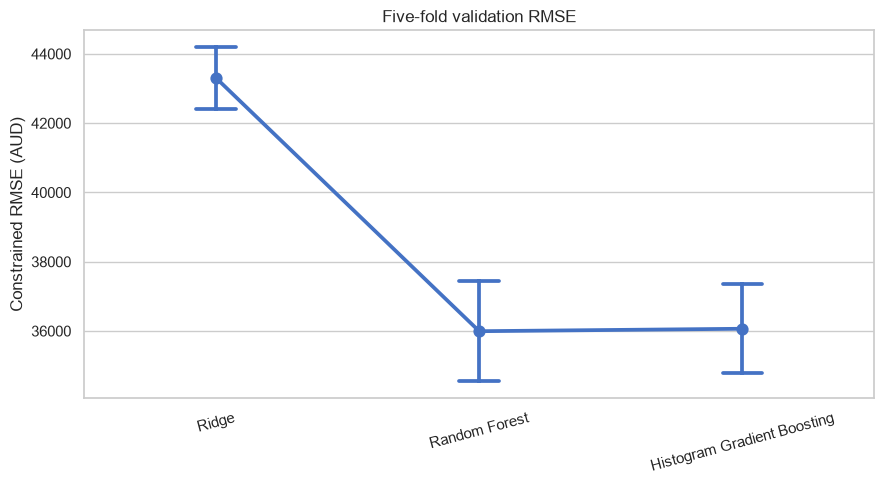

In [28]:
# Plot mean validation RMSE with one-standard-deviation error bars
fig, ax = plt.subplots(figsize=(9, 5))
sns.pointplot(
    data=validation_detail,
    x="model",
    y="constrained_rmse_aud",
    errorbar="sd",
    capsize=0.15,
    color="#4472C4",
    ax=ax,
)
ax.set(title="Five-fold validation RMSE", xlabel="", ylabel="Constrained RMSE (AUD)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### 8.1 Paired fold comparison and alternative metric

RMSE is the competition metric and appropriately penalises large lending errors, but a small number of large loans can dominate it. MAE is reported alongside RMSE because it describes the typical absolute dollar error and is easier to interpret operationally. MAPE is not suitable here because 26.8% of targets are zero.

Because every candidate uses the same folds, fold-level differences are paired. With only five folds these comparisons are descriptive; they should not be presented as precise inferential confidence intervals.

In [29]:
# Compare the two leading models on the same folds
rmse_by_fold = validation_detail.pivot(
    index="fold", columns="model", values="constrained_rmse_aud"
)
ordered_models = validation_summary.index.tolist()
best_name, second_name = ordered_models[:2]
# Positive values indicate a lower RMSE for the current best model
paired_difference = rmse_by_fold[second_name] - rmse_by_fold[best_name]

paired_fold_comparison = pd.Series(
    {
        "best_initial_model": best_name,
        "closest_challenger": second_name,
        "mean_rmse_advantage_of_best_aud": paired_difference.mean(),
        "folds_won_by_best": int((paired_difference > 0).sum()),
        "folds_won_by_challenger": int((paired_difference < 0).sum()),
        "largest_absolute_fold_difference_aud": paired_difference.abs().max(),
    }
)

display(rmse_by_fold.style.format("${:,.0f}"))
paired_fold_comparison

model,Histogram Gradient Boosting,Random Forest,Ridge
fold,,,
1,"$34,498","$34,346","$42,214"
2,"$37,169","$36,773","$44,148"
3,"$37,120","$36,982","$43,652"
4,"$34,868","$34,509","$42,507"
5,"$36,669","$37,362","$44,007"


best_initial_model                                    Random Forest
closest_challenger                      Histogram Gradient Boosting
mean_rmse_advantage_of_best_aud                              70.602
folds_won_by_best                                                 4
folds_won_by_challenger                                           1
largest_absolute_fold_difference_aud                        693.021
dtype: object

## 9. Out-of-fold error diagnosis

The best initial candidate is selected only for diagnosis. It is **not yet declared the final model**. Out-of-fold predictions provide an honest view of where the current approach fails without reusing training predictions.

In [30]:
# Diagnose where the best initial model makes its largest errors
best_initial_model = validation_summary.index[0]
best_oof = oof_predictions[best_initial_model]

# Use out-of-fold predictions so every residual comes from an unseen row
diagnostics = train[[
    "requested_amount_aud",
    "risk_review_flag",
    "credit_rating",
]].copy()
diagnostics["sanction_rate"] = sanction_rate
diagnostics["actual"] = y
diagnostics["prediction"] = best_oof
diagnostics["residual"] = diagnostics["actual"] - diagnostics["prediction"]
diagnostics["absolute_error"] = diagnostics["residual"].abs()
# Quintiles make error patterns comparable across requested-loan sizes
diagnostics["request_size_band"] = pd.qcut(
    diagnostics["requested_amount_aud"],
    q=5,
    duplicates="drop",
)

error_by_tier = (
    diagnostics.groupby("sanction_rate", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "n": len(group),
                "rmse_aud": rmse(group["actual"], group["prediction"]),
                "mean_error_aud": group["residual"].mean(),
            }
        ),
        include_groups=False,
    )
)

error_by_request_band = (
    diagnostics.groupby("request_size_band", observed=True)
    .apply(
        lambda group: pd.Series(
            {
                "n": len(group),
                "rmse_aud": rmse(group["actual"], group["prediction"]),
                "mean_absolute_error_aud": group["absolute_error"].mean(),
            }
        ),
        include_groups=False,
    )
)

print("Best initial candidate:", best_initial_model)
display(error_by_tier.style.format({"rmse_aud": "${:,.0f}", "mean_error_aud": "${:,.0f}"}))
display(error_by_request_band.style.format({"rmse_aud": "${:,.0f}", "mean_absolute_error_aud": "${:,.0f}"}))

Best initial candidate: Random Forest


,n,rmse_aud,mean_error_aud
sanction_rate,,,
0.000000,5177.000000,"$60,841","$-30,802"
0.650000,3257.000000,"$11,404","$6,673"
0.700000,5686.000000,"$16,258","$10,671"
0.750000,2568.000000,"$19,962","$14,114"
0.800000,2502.000000,"$29,563","$22,082"
0.850000,42.000000,"$83,623","$39,903"
0.900000,50.000000,"$69,049","$49,066"
1.000000,40.000000,"$76,421","$63,106"


,n,rmse_aud,mean_absolute_error_aud
request_size_band,,,
"(9467.479, 58154.086]",3865.000000,"$9,375","$5,535"
"(58154.086, 97642.096]",3864.000000,"$16,292","$9,666"
"(97642.096, 139523.094]",3864.000000,"$25,214","$15,139"
"(139523.094, 204700.392]",3864.000000,"$37,960","$23,279"
"(204700.392, 933695.43]",3865.000000,"$63,686","$36,322"


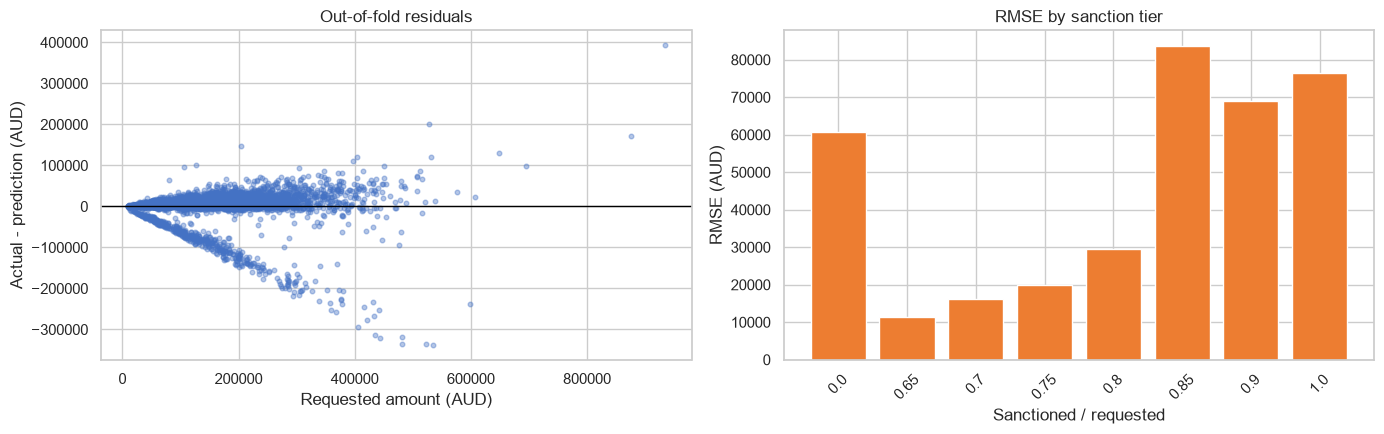

In [31]:
# Visualise residual bias by request size and sanction tier
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Sample points for readability; grouped RMSE still uses every observation
sample_index = train.sample(n=min(5_000, len(train)), random_state=RANDOM_STATE).index
axes[0].scatter(
    diagnostics.loc[sample_index, "requested_amount_aud"],
    diagnostics.loc[sample_index, "residual"],
    s=11,
    alpha=0.4,
    color="#4472C4",
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set(title="Out-of-fold residuals", xlabel="Requested amount (AUD)", ylabel="Actual - prediction (AUD)")

plot_error_by_tier = error_by_tier.reset_index()
axes[1].bar(
    plot_error_by_tier["sanction_rate"].astype(str),
    plot_error_by_tier["rmse_aud"],
    color="#ED7D31",
)
axes[1].set(title="RMSE by sanction tier", xlabel="Sanctioned / requested", ylabel="RMSE (AUD)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 10. Feature-engineering ablation

This controlled comparison isolates the contribution of three decisions while holding the model family, hyperparameters, clipping rule, and validation folds fixed. The purpose is to document measured effects, including changes that do not improve the score.

In [32]:
# Test whether the engineered features improve validation performance
# Rebuild preprocessing because each ablation has a different feature set
def make_hgb_pipeline(feature_frame):
    categorical = feature_frame.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()
    numeric = [column for column in feature_frame.columns if column not in categorical]
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", SimpleImputer(strategy="median"), numeric),
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                max_categories=254,
                            ),
                        ),
                    ]
                ),
                categorical,
            ),
        ]
    )
    categorical_mask = [False] * len(numeric) + [True] * len(categorical)
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.06,
                    max_leaf_nodes=31,
                    min_samples_leaf=20,
                    l2_regularization=1.0,
                    categorical_features=categorical_mask,
                    early_stopping=True,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


# Add transformations stepwise, including a deliberate test of the corrupt field
ablation_configurations = {
    "Cleaned raw features": {
        "use_income_backup": False,
        "add_business_features": False,
        "add_missing_indicators": False,
    },
    "+ ratios and missing indicators": {
        "use_income_backup": False,
        "add_business_features": True,
        "add_missing_indicators": True,
    },
    "+ property-age income backup": {
        "use_income_backup": True,
        "add_business_features": True,
        "add_missing_indicators": True,
    },
}

# Evaluate every configuration on the same folds for a fair comparison
ablation_rows = []
raw_predictors = train.drop(columns=TARGET)
for configuration_name, options in ablation_configurations.items():
    ablation_x = engineer_features(raw_predictors, **options)
    ablation_model = make_hgb_pipeline(ablation_x)

    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        fitted_model = clone(ablation_model)
        fitted_model.fit(ablation_x.iloc[train_index], y.iloc[train_index])
        prediction = np.clip(
            fitted_model.predict(ablation_x.iloc[valid_index]),
            0,
            requested_array[valid_index],
        )
        ablation_rows.append(
            {
                "configuration": configuration_name,
                "fold": fold_number,
                "rmse_aud": rmse(y.iloc[valid_index], prediction),
                "mae_aud": mean_absolute_error(y.iloc[valid_index], prediction),
                "feature_count": ablation_x.shape[1],
            }
        )

ablation_detail = pd.DataFrame(ablation_rows)
ablation_summary = (
    ablation_detail.groupby("configuration")
    .agg(
        feature_count=("feature_count", "first"),
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
        mean_mae_aud=("mae_aud", "mean"),
    )
    .sort_values("mean_rmse_aud")
)

# Report change relative to cleaned raw features; negative is an improvement
baseline_ablation_rmse = ablation_summary.loc["Cleaned raw features", "mean_rmse_aud"]
ablation_summary["rmse_change_vs_cleaned_raw_aud"] = (
    ablation_summary["mean_rmse_aud"] - baseline_ablation_rmse
)

ablation_summary.style.format(
    {
        "mean_rmse_aud": "${:,.0f}",
        "sd_rmse_aud": "${:,.0f}",
        "mean_mae_aud": "${:,.0f}",
        "rmse_change_vs_cleaned_raw_aud": "${:+,.0f}",
    }
)

,feature_count,mean_rmse_aud,sd_rmse_aud,mean_mae_aud,rmse_change_vs_cleaned_raw_aud
configuration,,,,,
+ ratios and missing indicators,50,"$36,065","$1,283","$19,047",$-46
+ property-age income backup,50,"$36,074","$1,319","$18,979",$-37
Cleaned raw features,31,"$36,111","$1,185","$19,087",$+0


## 11. Feature selection check for `property_ref`

`property_ref` is repeated across train and test, so it may contain some group information. However, it is still an internal identifier with 999 categories and no direct numerical meaning. The leading model is compared with and without this variable using the same five folds.

In [33]:
# Compare the leading model with and without property_ref
X_without_property_ref = X.drop(columns=["property_ref"])
X_kaggle_without_property_ref = X_kaggle.drop(columns=["property_ref"])

# Rebuild the preprocessor because the selected feature set has one less category
selected_categorical_features = X_without_property_ref.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()
selected_numeric_features = [
    column
    for column in X_without_property_ref.columns
    if column not in selected_categorical_features
]
selected_ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), selected_numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            max_categories=254,
                        ),
                    ),
                ]
            ),
            selected_categorical_features,
        ),
    ]
)
selected_categorical_mask = (
    [False] * len(selected_numeric_features)
    + [True] * len(selected_categorical_features)
)

property_ref_rows = [
    {
        "configuration": "With property_ref",
        "fold": int(row.fold),
        "rmse_aud": row.constrained_rmse_aud,
    }
    for row in validation_detail.loc[
        validation_detail["model"] == "Random Forest"
    ].itertuples()
]

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
    model_without_property_ref = Pipeline(
        steps=[
            ("preprocess", clone(selected_ordinal_preprocessor)),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=250,
                    min_samples_leaf=2,
                    max_features=0.8,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model_without_property_ref.fit(
        X_without_property_ref.iloc[train_index], y.iloc[train_index]
    )
    prediction = np.clip(
        model_without_property_ref.predict(
            X_without_property_ref.iloc[valid_index]
        ),
        0,
        requested_array[valid_index],
    )
    property_ref_rows.append(
        {
            "configuration": "Without property_ref",
            "fold": fold_number,
            "rmse_aud": rmse(y.iloc[valid_index], prediction),
        }
    )

property_ref_detail = pd.DataFrame(property_ref_rows)
property_ref_summary = (
    property_ref_detail.groupby("configuration")
    .agg(
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
    )
    .sort_values("mean_rmse_aud")
)

# Use the simpler selected feature set in the remaining experiments
X_selected = X_without_property_ref
X_kaggle_selected = X_kaggle_without_property_ref

property_ref_summary.style.format("${:,.0f}")

,mean_rmse_aud,sd_rmse_aud
configuration,,
Without property_ref,"$35,956","$1,427"
With property_ref,"$35,994","$1,447"


#### Decision on `property_ref`

Removing `property_ref` reduces the Random Forest mean RMSE from AUD 35,994 to AUD 35,956. The improvement of AUD 38 is very small, so it is not evidence of a major performance gain. However, removing the identifier gives a slightly better result and a simpler feature set, so it is excluded from the remaining experiments.

## 12. Small hyperparameter comparison

The initial results suggest that Random Forest and Histogram Gradient Boosting are the only model families worth tuning at this stage. A small manual search is used instead of a large grid so that every option can be explained and evaluated on the same five folds.

In [34]:
# Compare a small set of reasonable tree-model configurations
tuning_candidates = {
    "RF: smaller leaves": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=1,
        max_features=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "RF: all features": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        max_features=1.0,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HGB: initial settings": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        categorical_features=selected_categorical_mask,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    "HGB: lower learning rate": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.5,
        categorical_features=selected_categorical_mask,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    "HGB: more leaves": HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_leaf_nodes=63,
        min_samples_leaf=20,
        l2_regularization=1.0,
        categorical_features=selected_categorical_mask,
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
}

# Reuse the selected Random Forest baseline already calculated above
tuning_rows = [
    {
        "configuration": "RF: initial settings",
        "fold": int(row.fold),
        "rmse_aud": row.rmse_aud,
    }
    for row in property_ref_detail.loc[
        property_ref_detail["configuration"] == "Without property_ref"
    ].itertuples()
]

for configuration_name, estimator in tuning_candidates.items():
    started = time.time()
    for fold_number, (train_index, valid_index) in enumerate(folds, start=1):
        tuned_model = Pipeline(
            steps=[
                ("preprocess", clone(selected_ordinal_preprocessor)),
                ("model", clone(estimator)),
            ]
        )
        tuned_model.fit(X_selected.iloc[train_index], y.iloc[train_index])
        prediction = np.clip(
            tuned_model.predict(X_selected.iloc[valid_index]),
            0,
            requested_array[valid_index],
        )
        tuning_rows.append(
            {
                "configuration": configuration_name,
                "fold": fold_number,
                "rmse_aud": rmse(y.iloc[valid_index], prediction),
            }
        )
    print(
        f"Finished {configuration_name} in "
        f"{time.time() - started:.1f} seconds"
    )

tuning_detail = pd.DataFrame(tuning_rows)
tuning_summary = (
    tuning_detail.groupby("configuration")
    .agg(
        mean_rmse_aud=("rmse_aud", "mean"),
        sd_rmse_aud=("rmse_aud", "std"),
    )
    .sort_values("mean_rmse_aud")
)

tuning_summary.style.format("${:,.0f}")

Finished RF: smaller leaves in 45.1 seconds


Finished RF: all features in 50.9 seconds


Finished HGB: initial settings in 6.0 seconds


Finished HGB: lower learning rate in 6.7 seconds


Finished HGB: more leaves in 13.3 seconds


,mean_rmse_aud,sd_rmse_aud
configuration,,
RF: initial settings,"$35,956","$1,427"
HGB: initial settings,"$35,975","$1,232"
HGB: lower learning rate,"$36,005","$1,285"
RF: all features,"$36,088","$1,445"
HGB: more leaves,"$36,120","$1,256"
RF: smaller leaves,"$36,277","$1,420"


#### Interpretation of the tuning comparison

The original Random Forest settings remain the best option, with a mean RMSE of AUD 35,956 after removing `property_ref`. The initial HGB settings are very close at AUD 35,975, while all parameter changes make the average RMSE worse. Smaller Random Forest leaves increase the error to AUD 36,277, suggesting additional overfitting. Since fold-to-fold variation is much larger than these small differences, no tuned variant is selected.

## 13. Next experiments before choosing the final model

The next iteration will keep using the same five folds so the model comparison remains fair:

1. **Explain the main influences.** Add statistical evidence that combines the existing correlations and category rates with an interpretable model.
2. **Create a reproducible first submission.** Fit the selected Random Forest benchmark on all labelled rows and verify the exact Kaggle file format.
3. **Begin the competitive experiments.** Compare target-aware approaches and stronger boosting methods only after the benchmark submission is saved. Every change must still be evaluated with the same folds.
4. **Choose the final model carefully.** Use cross-validation as the main selection evidence and treat the public leaderboard as a secondary check because it contains only 20% of the test rows.

## 14. Evidence table for the report

This final table gathers the core numeric evidence produced above. It is a drafting aid: the report should explain each finding, decision, and measured effect rather than paste the table without interpretation.

In [35]:
# Collect report-ready evidence and modelling decisions
best_ablation_name = ablation_summary.index[0]

report_evidence = pd.DataFrame(
    [
        {
            "topic": "Target zeros",
            "finding": f"{int((y == 0).sum()):,} rows ({100 * (y == 0).mean():.2f}%)",
            "decision_or_implication": "Stratify folds by sanction tier; avoid MAPE.",
        },
        {
            "topic": "Encoded missing values",
            "finding": f"{int(sentinel_counts['training_minus_999'].sum()):,} training values equal -999",
            "decision_or_implication": "Convert to NaN before learned imputation.",
        },
        {
            "topic": "Corrupted property age",
            "finding": f"{int(exact_matches.sum()):,}/{len(income_property_overlap):,} overlaps equal annual income",
            "decision_or_implication": "Drop its numeric values; retain the missingness indicator.",
        },
        {
            "topic": "Best initial model",
            "finding": f"{best_initial_model}: RMSE ${validation_summary.loc[best_initial_model, 'mean_constrained_rmse_aud']:,.0f}",
            "decision_or_implication": "Use as the current benchmark, not the final model.",
        },
        {
            "topic": "Best tested feature configuration",
            "finding": f"{best_ablation_name}: RMSE ${ablation_summary.loc[best_ablation_name, 'mean_rmse_aud']:,.0f}",
            "decision_or_implication": "Retain only transformations supported by validation.",
        },
        {
            "topic": "Property reference",
            "finding": f"Without property_ref: RMSE ${property_ref_summary.loc['Without property_ref', 'mean_rmse_aud']:,.0f}",
            "decision_or_implication": "Exclude the identifier because the simpler model performs slightly better.",
        },
        {
            "topic": "Small tuning comparison",
            "finding": f"{tuning_summary.index[0]}: RMSE ${tuning_summary.iloc[0]['mean_rmse_aud']:,.0f}",
            "decision_or_implication": "Keep the initial Random Forest settings; tested changes did not improve RMSE.",
        },
    ]
)
report_evidence

,topic,finding,decision_or_implication
0,Target zeros,"5,177 rows (26.79%)",Stratify folds by sanction tier; avoid MAPE.
1,Encoded missing values,406 training values equal -999,Convert to NaN before learned imputation.
2,Corrupted property age,"11,524/11,524 overlaps equal annual income",Drop its numeric values; retain the missingnes...
3,Best initial model,"Random Forest: RMSE $35,994","Use as the current benchmark, not the final mo..."
4,Best tested feature configuration,"+ ratios and missing indicators: RMSE $36,065",Retain only transformations supported by valid...
5,Property reference,"Without property_ref: RMSE $35,956",Exclude the identifier because the simpler mod...
6,Small tuning comparison,"RF: initial settings: RMSE $35,956",Keep the initial Random Forest settings; teste...


## 15. Reproducibility record

Record these versions in the final README, together with the command used to run the notebook or script.

In [36]:
# Record the software environment needed for reproducibility
versions = pd.Series(
    {
        "Python": sys.version.split()[0],
        "Platform": platform.platform(),
        "NumPy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "random_seed": RANDOM_STATE,
    }
)
versions

Python                               3.11.15
Platform        macOS-26.6.2-arm64-arm-64bit
NumPy                                  2.4.6
pandas                                 3.0.5
scikit-learn                           1.9.0
random_seed                               42
dtype: object